# HW13 — токенизация текста, инференс BERT и базовый fine-tuning

Обязательная часть выполнена на датасете `emotion` с одним основным экспериментом fine-tuning.

## План
1. Импорты, seed, устройство.
2. Загрузка и sanity-check датасета.
3. Разбор токенизации на нескольких примерах.
4. Инференс готовой pretrained-модели.
5. Fine-tuning одной BERT-подобной модели.
6. Финальная оценка (`accuracy`, `f1_macro`), матрица ошибок и примеры предсказаний.

In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset, DatasetDict
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    pipeline,
)

import datasets
import transformers
import sklearn

print('torch:', torch.__version__)
print('datasets:', datasets.__version__)
print('transformers:', transformers.__version__)
print('sklearn:', sklearn.__version__)

C:\Users\kiril\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch: 2.11.0+cpu
datasets: 4.8.4
transformers: 5.5.0
sklearn: 1.8.0


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

DATASET_NAME = "emotion"
INFERENCE_MODEL_NAME = "distilbert-base-uncased-finetuned-sst-2-english"
FINETUNE_MODEL_NAME = "distilbert-base-uncased"

MAX_LENGTH = 96
TRAIN_MAX_SAMPLES = 1200
VAL_MAX_SAMPLES = 400
TEST_MAX_SAMPLES = 400
NUM_EPOCHS = 1
TRAIN_BS = 16
EVAL_BS = 32
LR = 3e-5

ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("Artifacts dir:", ARTIFACTS_DIR.resolve())

Device: cpu
Artifacts dir: C:\ucheba\ai\Damir\homeworks\HW13\artifacts


## 1. Данные и первичный анализ

In [3]:
raw_datasets = load_dataset(DATASET_NAME)
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [4]:
label_names = raw_datasets["train"].features["label"].names
id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in id2label.items()}

split_sizes = {split: len(raw_datasets[split]) for split in raw_datasets.keys()}
print("Split sizes:", split_sizes)
print("Classes:", label_names)

preview_df = pd.DataFrame(raw_datasets["train"][:5])
preview_df["label_name"] = preview_df["label"].map(id2label)
display(preview_df[["text", "label", "label_name"]])

print("Постановка: multi-class классификация эмоций по тексту (6 классов).")

Split sizes: {'train': 16000, 'validation': 2000, 'test': 2000}
Classes: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


Постановка: multi-class классификация эмоций по тексту (6 классов).


## 2. Токенизация (базовый разбор)

In [5]:
tokenizer_demo = AutoTokenizer.from_pretrained(FINETUNE_MODEL_NAME)
print("Tokenizer:", tokenizer_demo.__class__.__name__)
print("Special tokens:", tokenizer_demo.special_tokens_map)

sample_indices = [0, 1, 2, 3, 4]
sample_texts = [raw_datasets["train"][i]["text"] for i in sample_indices]
sample_true_labels = [id2label[raw_datasets["train"][i]["label"]] for i in sample_indices]

rows = []
for text, true_label in zip(sample_texts, sample_true_labels):
    encoded = tokenizer_demo(text, add_special_tokens=True)
    tokens = tokenizer_demo.convert_ids_to_tokens(encoded["input_ids"])
    rows.append(
        {
            "text": text,
            "true_label": true_label,
            "tokens": tokens[:20],
            "input_ids": encoded["input_ids"][:20],
            "attention_mask": encoded["attention_mask"][:20],
            "n_tokens": len(encoded["input_ids"]),
        }
    )

token_demo_df = pd.DataFrame(rows)
display(token_demo_df[["text", "true_label", "tokens", "input_ids", "attention_mask", "n_tokens"]])

Tokenizer: BertTokenizer
Special tokens: {'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}


,text,true_label,tokens,input_ids,attention_mask,n_tokens
0,i didnt feel humiliated,sadness,"[[CLS], i, didn, ##t, feel, humiliated, [SEP]]","[101, 1045, 2134, 2102, 2514, 26608, 102]","[1, 1, 1, 1, 1, 1, 1]",7
1,i can go from feeling so hopeless to so damned...,sadness,"[[CLS], i, can, go, from, feeling, so, hopeles...","[101, 1045, 2064, 2175, 2013, 3110, 2061, 2062...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",23
2,im grabbing a minute to post i feel greedy wrong,anger,"[[CLS], im, grabbing, a, minute, to, post, i, ...","[101, 10047, 9775, 1037, 3371, 2000, 2695, 104...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",12
3,i am ever feeling nostalgic about the fireplac...,love,"[[CLS], i, am, ever, feeling, nos, ##tal, ##gi...","[101, 1045, 2572, 2412, 3110, 16839, 9080, 128...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",22
4,i am feeling grouchy,anger,"[[CLS], i, am, feeling, gr, ##ou, ##chy, [SEP]]","[101, 1045, 2572, 3110, 24665, 7140, 11714, 102]","[1, 1, 1, 1, 1, 1, 1, 1]",8


In [6]:
short_text = "I feel great"
long_text = " ".join(["This movie is surprisingly emotional and intense"] * 40)

enc = tokenizer_demo(
    [short_text, long_text],
    padding="max_length",
    truncation=True,
    max_length=32,
    return_tensors="pt",
)

print("input_ids shape:", tuple(enc["input_ids"].shape))
print("attention_mask shape:", tuple(enc["attention_mask"].shape))
print("Short text attention sum:", int(enc["attention_mask"][0].sum()))
print("Long text attention sum (after truncation):", int(enc["attention_mask"][1].sum()))
print("Decoded long text (truncated):")
print(tokenizer_demo.decode(enc["input_ids"][1]))

input_ids shape: (2, 32)
attention_mask shape: (2, 32)
Short text attention sum: 5
Long text attention sum (after truncation): 32
Decoded long text (truncated):
[CLS] this movie is surprisingly emotional and intense this movie is surprisingly emotional and intense this movie is surprisingly emotional and intense this movie is surprisingly emotional and intense this movie [SEP]


## 3. Инференс готовой pretrained-модели

In [7]:
pipe_device = 0 if DEVICE == "cuda" else -1
sentiment_pipe = pipeline(
    "text-classification",
    model=INFERENCE_MODEL_NAME,
    tokenizer=INFERENCE_MODEL_NAME,
    device=pipe_device,
)

inference_results = sentiment_pipe(sample_texts)
inf_df = pd.DataFrame(
    {
        "text": sample_texts,
        "true_emotion_label": sample_true_labels,
        "pretrained_label": [x["label"] for x in inference_results],
        "pretrained_score": [x["score"] for x in inference_results],
    }
)
display(inf_df)

print(
    "Комментарий: модель обучена на sentiment (SST-2), а не на emotion-классах, "
    "поэтому её метки напрямую не совпадают с нашей целевой постановкой."
)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 7725.14it/s]

,text,true_emotion_label,pretrained_label,pretrained_score
0,i didnt feel humiliated,sadness,POSITIVE,0.891336
1,i can go from feeling so hopeless to so damned...,sadness,POSITIVE,0.966551
2,im grabbing a minute to post i feel greedy wrong,anger,NEGATIVE,0.999305
3,i am ever feeling nostalgic about the fireplac...,love,POSITIVE,0.965797
4,i am feeling grouchy,anger,NEGATIVE,0.999391


Комментарий: модель обучена на sentiment (SST-2), а не на emotion-классах, поэтому её метки напрямую не совпадают с нашей целевой постановкой.


## 4. Fine-tuning для классификации текста (с выбором лучшего варианта по validation)


In [8]:
def take_subset(ds, n, seed=SEED):
    n = min(n, len(ds))
    return ds.shuffle(seed=seed).select(range(n))

subset_raw = DatasetDict(
    {
        "train": take_subset(raw_datasets["train"], TRAIN_MAX_SAMPLES),
        "validation": take_subset(raw_datasets["validation"], VAL_MAX_SAMPLES),
        "test": take_subset(raw_datasets["test"], TEST_MAX_SAMPLES),
    }
)

print({k: len(v) for k, v in subset_raw.items()})

{'train': 1200, 'validation': 400, 'test': 400}


In [9]:
tokenizer = AutoTokenizer.from_pretrained(FINETUNE_MODEL_NAME)


def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)


tokenized = subset_raw.map(tokenize_batch, batched=True)
tokenized = tokenized.remove_columns(["text"]).rename_column("label", "labels")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


def build_model():
    model = AutoModelForSequenceClassification.from_pretrained(
        FINETUNE_MODEL_NAME,
        num_labels=len(label_names),
        id2label=id2label,
        label2id=label2id,
    )
    model.to(DEVICE)
    return model


print("Fine-tune base model:", FINETUNE_MODEL_NAME)
print("num_labels:", len(label_names))


Fine-tune base model: distilbert-base-uncased
num_labels: 6


In [10]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    if isinstance(logits, tuple):
        logits = logits[0]
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
    }

import shutil
shutil.rmtree(ARTIFACTS_DIR / "trainer_output", ignore_errors=True)

common_args = dict(
    per_device_train_batch_size=TRAIN_BS,
    per_device_eval_batch_size=EVAL_BS,
    num_train_epochs=NUM_EPOCHS,
    weight_decay=0.01,
    logging_steps=25,
    report_to="none",
    seed=SEED,
)


def make_training_args(run_output_dir, learning_rate):
    run_args = dict(common_args)
    run_args["output_dir"] = str(run_output_dir)
    run_args["learning_rate"] = learning_rate

    try:
        return TrainingArguments(
            evaluation_strategy="epoch",
            save_strategy="no",
            **run_args,
        )
    except TypeError:
        return TrainingArguments(
            eval_strategy="epoch",
            save_strategy="no",
            **run_args,
        )


def build_trainer(model, training_args):
    trainer_kwargs = dict(
        model=model,
        args=training_args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["validation"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    try:
        return Trainer(processing_class=tokenizer, **trainer_kwargs)
    except TypeError:
        return Trainer(tokenizer=tokenizer, **trainer_kwargs)


def run_variant(run_name, learning_rate):
    run_dir = ARTIFACTS_DIR / "trainer_output" / run_name
    shutil.rmtree(run_dir, ignore_errors=True)

    training_args = make_training_args(run_dir, learning_rate)
    trainer = build_trainer(build_model(), training_args)
    train_result = trainer.train()

    try:
        from transformers.utils.notebook import NotebookProgressCallback

        trainer.remove_callback(NotebookProgressCallback)
    except Exception:
        pass

    val_metrics = trainer.evaluate(tokenized["validation"])

    return {
        "name": run_name,
        "learning_rate": learning_rate,
        "trainer": trainer,
        "train_result": train_result,
        "val_metrics": val_metrics,
    }


In [11]:
candidate_variants = [
    {"name": "lr_2e-5", "learning_rate": 2e-5},
    {"name": "lr_3e-5", "learning_rate": 3e-5},
    {"name": "lr_5e-5", "learning_rate": 5e-5},
]

experiment_rows = []
best_score = (-np.inf, -np.inf)
best_result = None
best_trainer = None

for variant in candidate_variants:
    print(f"\n=== Training variant: {variant['name']} (lr={variant['learning_rate']}) ===")
    result = run_variant(variant["name"], variant["learning_rate"])

    val_acc = float(result["val_metrics"].get("eval_accuracy", np.nan))
    val_f1 = float(result["val_metrics"].get("eval_f1_macro", np.nan))

    experiment_rows.append(
        {
            "variant": result["name"],
            "learning_rate": result["learning_rate"],
            "val_accuracy": val_acc,
            "val_f1_macro": val_f1,
        }
    )

    print("train_loss:", round(float(result["train_result"].training_loss), 4))
    print("val_accuracy:", round(val_acc, 4))
    print("val_f1_macro:", round(val_f1, 4))

    current_score = (val_f1, val_acc)
    if current_score > best_score:
        if best_trainer is not None:
            best_trainer.model.to("cpu")
            del best_trainer
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        best_score = current_score
        best_result = {
            "name": result["name"],
            "learning_rate": result["learning_rate"],
            "val_metrics": result["val_metrics"],
        }
        best_trainer = result["trainer"]
    else:
        result["trainer"].model.to("cpu")

    del result
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

results_table = pd.DataFrame(experiment_rows)
results_table = results_table.sort_values(["val_f1_macro", "val_accuracy"], ascending=False).reset_index(drop=True)

print("\nBest variant by validation f1_macro:", best_result["name"])
print("Best learning_rate:", float(best_result["learning_rate"]))
display(results_table)



=== Training variant: lr_2e-5 (lr=2e-05) ===


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 4644.85it/s]


DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


C:\Users\kiril\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

C:\Users\kiril\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.061460,1.143733,0.575000,0.282315


C:\Users\kiril\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


train_loss: 1.3546
val_accuracy: 0.575
val_f1_macro: 0.2823

Best variant by validation f1_macro: lr_5e-5
Best learning_rate: 5e-05


,variant,learning_rate,val_accuracy,val_f1_macro
0,lr_5e-5,0.00005,0.5750,0.282315
1,lr_3e-5,0.00003,0.5375,0.223121
2,lr_2e-5,0.00002,0.4950,0.204942


In [12]:
trainer = best_trainer
val_metrics = best_result["val_metrics"]

try:
    from transformers.utils.notebook import NotebookProgressCallback

    trainer.remove_callback(NotebookProgressCallback)
except Exception:
    pass

print("Selected best variant by validation:")
print("name:", best_result["name"])
print("learning_rate:", best_result["learning_rate"])
print("eval_accuracy:", round(float(val_metrics.get("eval_accuracy", np.nan)), 4))
print("eval_f1_macro:", round(float(val_metrics.get("eval_f1_macro", np.nan)), 4))

test_metrics = trainer.evaluate(tokenized["test"])

print("Test metrics (best variant only):")
for k, v in test_metrics.items():
    if isinstance(v, (int, float)):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

pred_out = trainer.predict(tokenized["test"])
test_logits = pred_out.predictions[0] if isinstance(pred_out.predictions, tuple) else pred_out.predictions
test_true = pred_out.label_ids
test_pred = np.argmax(test_logits, axis=-1)
test_probs = torch.softmax(torch.tensor(test_logits), dim=-1).numpy()

test_acc = accuracy_score(test_true, test_pred)
test_f1_macro = f1_score(test_true, test_pred, average="macro")
print("Final test_accuracy:", round(test_acc, 4))
print("Final test_f1_macro:", round(test_f1_macro, 4))


Selected best variant by validation:
name: lr_5e-5
learning_rate: 5e-05
eval_accuracy: 0.575
eval_f1_macro: 0.2823


C:\Users\kiril\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test metrics (best variant only):
eval_loss: 0.9770
eval_accuracy: 0.6675
eval_f1_macro: 0.3015
eval_runtime: 7.2977
eval_samples_per_second: 54.8120
eval_steps_per_second: 1.7810
epoch: 1.0000


C:\Users\kiril\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Final test_accuracy: 0.6675
Final test_f1_macro: 0.3015


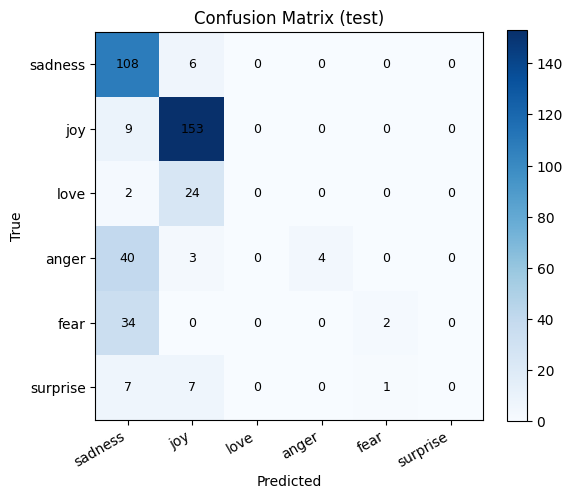

Saved: C:\ucheba\ai\Damir\homeworks\HW13\artifacts\confusion_matrix.png


In [13]:
cm = confusion_matrix(test_true, test_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Confusion Matrix (test)")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks(range(len(label_names)))
ax.set_yticks(range(len(label_names)))
ax.set_xticklabels(label_names, rotation=30, ha="right")
ax.set_yticklabels(label_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=9)

plt.colorbar(im, ax=ax)
plt.tight_layout()

cm_path = ARTIFACTS_DIR / "confusion_matrix.png"
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", cm_path.resolve())

In [14]:
test_texts = subset_raw["test"]["text"]

sample_pred_df = pd.DataFrame(
    {
        "text": test_texts,
        "true_label": [id2label[int(x)] for x in test_true],
        "pred_label": [id2label[int(x)] for x in test_pred],
        "confidence": test_probs.max(axis=1),
    }
)

sample_pred_path = ARTIFACTS_DIR / "sample_predictions.csv"
sample_pred_df.to_csv(sample_pred_path, index=False, encoding="utf-8")
print("Saved:", sample_pred_path.resolve())

display(sample_pred_df.head(10))

Saved: C:\ucheba\ai\Damir\homeworks\HW13\artifacts\sample_predictions.csv


,text,true_label,pred_label,confidence
0,i was feeling really troubled and down over wh...,sadness,sadness,0.546531
1,i feel so thrilled to have three such distingu...,joy,joy,0.710476
2,i feel is that the most likeable characters ar...,joy,joy,0.724431
3,i tune out the rest of the world and focus on ...,joy,joy,0.710354
4,i sit here writing this i feel unhappy inside,sadness,sadness,0.533899
5,im feeling and if ive liked being pregnant,love,joy,0.694568
6,im very hurt and i feel unimportant,sadness,sadness,0.480534
7,i used to be able to hang around talk with the...,anger,sadness,0.442980
8,i don t have the feeling of divine vibrations,joy,joy,0.695528
9,i vented my feelings towards the pathetic excu...,sadness,sadness,0.517138


In [15]:
errors_df = sample_pred_df[sample_pred_df["true_label"] != sample_pred_df["pred_label"]].copy()
errors_df = errors_df.sort_values("confidence", ascending=False)

print("Ошибок на test:", len(errors_df), "из", len(sample_pred_df))
display(errors_df.head(8))

print("Короткий комментарий:")
print(
    "Чаще всего ошибки возникают на эмоционально близких классах "
    "(например, joy/love или anger/fear), где контекст короткий и неоднозначный."
)

Ошибок на test: 133 из 400


,text,true_label,pred_label,confidence
385,ive got a off sale the ad says starting tomorr...,love,joy,0.742971
62,i feel about this part of my life and how trea...,love,joy,0.739364
309,i just got back from another miler faster than...,surprise,joy,0.736950
136,i feel like now its more of sweet apple now,love,joy,0.736272
249,im feeling generous today heres one more you m...,love,joy,0.733338
298,i love and captured an atmospheric feeling in ...,surprise,joy,0.728110
134,i go through my day feeling your movements and...,surprise,joy,0.727981
132,i understand that they are reacting to what we...,love,joy,0.727783


Короткий комментарий:
Чаще всего ошибки возникают на эмоционально близких классах (например, joy/love или anger/fear), где контекст короткий и неоднозначный.


In [16]:
summary = {
    "dataset": DATASET_NAME,
    "inference_model": INFERENCE_MODEL_NAME,
    "finetune_model": FINETUNE_MODEL_NAME,
    "train_size": len(subset_raw["train"]),
    "validation_size": len(subset_raw["validation"]),
    "test_size": len(subset_raw["test"]),
    "max_length": MAX_LENGTH,
    "train_batch_size": TRAIN_BS,
    "eval_batch_size": EVAL_BS,
    "num_epochs": NUM_EPOCHS,
    "selected_variant": best_result["name"],
    "selected_learning_rate": float(best_result["learning_rate"]),
    "best_validation_accuracy": float(val_metrics.get("eval_accuracy", np.nan)),
    "best_validation_f1_macro": float(val_metrics.get("eval_f1_macro", np.nan)),
    "test_accuracy": float(test_acc),
    "test_f1_macro": float(test_f1_macro),
}

summary_df = pd.DataFrame([summary])
display(summary_df)

summary_path = ARTIFACTS_DIR / "metrics_summary.csv"
summary_df.to_csv(summary_path, index=False)
print("Saved:", summary_path.resolve())


,dataset,inference_model,finetune_model,train_size,validation_size,test_size,max_length,train_batch_size,eval_batch_size,num_epochs,selected_variant,selected_learning_rate,best_validation_accuracy,best_validation_f1_macro,test_accuracy,test_f1_macro
0,emotion,distilbert-base-uncased-finetuned-sst-2-english,distilbert-base-uncased,1200,400,400,96,16,32,1,lr_5e-5,0.00005,0.575,0.282315,0.6675,0.301549


Saved: C:\ucheba\ai\Damir\homeworks\HW13\artifacts\metrics_summary.csv


## Короткий вывод
- Токенизация показывает преобразование текста в `input_ids`/`attention_mask` с special tokens и контролем длины через `padding`/`truncation`.
- Готовая sentiment-модель даёт ориентировочные предсказания, но не совпадает по пространству классов с задачей `emotion`.
- Для fine-tuning выполнено несколько вариантов с разными `learning_rate`; лучший вариант выбран по `validation` (`eval_f1_macro`) и только после этого один раз оценён на `test`.
